<a href="https://colab.research.google.com/github/FivaKit/stocks/blob/main/IMOEX_fixed_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогнозирование динамики IMOEX

Модель прогнозирует не абсолютную цену, а будущую логарифмическую доходность:

$$r_{t,h}=\log(P_{t+h}/P_t).$$

Данные делятся только по времени. `test` не используется при обучении и выборе эпохи.

In [ ]:
%pip install -q apimoex catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [ ]:
import requests
import apimoex
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from catboost import CatBoostRegressor
from tqdm.auto import tqdm

np.random.seed(42)
torch.manual_seed(42)

## Данные IMOEX

Используются дневные свечи индекса Московской биржи.

In [ ]:
with requests.Session() as session:
  data = apimoex.get_market_candles(
      session=session,
      security='IMOEX',
      interval=24,
      start='2014-01-01',
      columns=('begin', 'open', 'high', 'low', 'close', 'value'),
      market='index',
      engine='stock'
  )

df = pd.DataFrame(data)
df['begin'] = pd.to_datetime(df['begin'])
df = df.sort_values('begin').drop_duplicates('begin').set_index('begin')

for col in ['open', 'high', 'low', 'close', 'value']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['open', 'high', 'low', 'close'])
df.tail()

,open,high,low,close,value
begin,,,,,
2026-08-27,2060.60,2105.95,2054.64,2093.40,5.857022e+10
2026-08-28,2113.27,2121.94,2070.46,2114.93,6.137399e+10
2026-08-31,2138.18,2188.97,2123.69,2178.87,6.173732e+10
2026-09-01,2175.35,2204.62,2167.97,2187.33,5.785794e+10
2026-09-02,2173.96,2183.31,2161.32,2173.10,2.729727e+10


## Признаки и target

Вместо уровня цены используются относительные признаки. Они заметно меньше зависят от того, находится индекс около 1500 или около 4000 пунктов.

In [ ]:
horizon = 5
window = 60

close = df['close']
log_ret = np.log(close / close.shift(1))

features = pd.DataFrame(index=df.index)
features['ret_1'] = log_ret
features['ret_5'] = np.log(close / close.shift(5))
features['ret_20'] = np.log(close / close.shift(20))
features['ma_5'] = close / close.rolling(5).mean() - 1
features['ma_20'] = close / close.rolling(20).mean() - 1
features['vol_5'] = log_ret.rolling(5).std()
features['vol_20'] = log_ret.rolling(20).std()
features['range'] = (df['high'] - df['low']) / close
features['open_close'] = (df['close'] - df['open']) / df['open']

# target в момент t использует цену только в t+horizon
future_return = np.log(close.shift(-horizon) / close)

valid = features.notna().all(axis=1)
features = features.loc[valid]
future_return = future_return.loc[features.index]
close = close.loc[features.index]

len(features), features.head()

(3163,
                ret_1     ret_5    ret_20      ma_5     ma_20     vol_5  \
 begin                                                                    
 2014-02-04 -0.001165 -0.019521 -0.017192 -0.008100 -0.022976  0.003373   
 2014-02-05  0.010245 -0.004789 -0.004571  0.003080 -0.012692  0.007105   
 2014-02-06  0.007322  0.002389  0.001064  0.009964 -0.005489  0.008047   
 2014-02-07  0.008000  0.016387  0.006303  0.014718  0.002183  0.007656   
 2014-02-10 -0.001489  0.022912 -0.000867  0.008578  0.000735  0.005503   
 
               vol_20     range  open_close  
 begin                                       
 2014-02-04  0.005586  0.011331   -0.000943  
 2014-02-05  0.006095  0.015941    0.009695  
 2014-02-06  0.006315  0.010057    0.007349  
 2014-02-07  0.006538  0.011255    0.009077  
 2014-02-10  0.006424  0.006564   -0.001312  )

## Хронологическое разбиение

`StandardScaler` обучается только на train. Для последних объектов train target не должен заходить в validation, поэтому при построении окон учитывается `horizon`.

In [ ]:
n = len(features)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

scaler = StandardScaler()
scaler.fit(features.iloc[:train_end])
features_sc = scaler.transform(features)

target = future_return.to_numpy(dtype=np.float32)

print('train до:', features.index[train_end - 1].date())
print('validation:', features.index[train_end].date(), '-', features.index[val_end - 1].date())
print('test с:', features.index[val_end].date())

train до: 2022-12-08
validation: 2022-12-09 - 2024-10-18
test с: 2024-10-21


In [ ]:
def make_samples(data, targets, window, horizon, start, end):
  samples = []

  first = max(start, window - 1)
  last = min(end, len(data) - horizon)

  for i in range(first, last):
    if np.isnan(targets[i]):
      continue

    samples.append({
        'args': data[i - window + 1:i + 1],
        'target': targets[i],
        'origin': i
    })

  return samples


# target каждого train-объекта полностью лежит внутри train
train_data = make_samples(features_sc, target, window, horizon, 0, train_end - horizon)
val_data = make_samples(features_sc, target, window, horizon, train_end, val_end - horizon)
test_data = make_samples(features_sc, target, window, horizon, val_end, n - horizon)

vec_dim = features_sc.shape[1]
len(train_data), len(val_data), len(test_data), vec_dim

(2150, 469, 470, 9)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
class MyDataset(Dataset):
  def __init__(self, dataset):
    self.dataset = dataset

  def __getitem__(self, ind):
    return self.dataset[ind]

  def __len__(self):
    return len(self.dataset)


def collate_fn(input_batch):
  batch = np.stack([d['args'] for d in input_batch])
  targets = np.array([d['target'] for d in input_batch])

  batch = torch.tensor(batch, dtype=torch.float32, device=device)
  targets = torch.tensor(targets, dtype=torch.float32, device=device)
  return batch, targets


train_dataloader = DataLoader(MyDataset(train_data), batch_size=32, shuffle=False, collate_fn=collate_fn)
val_dataloader = DataLoader(MyDataset(val_data), batch_size=64, shuffle=False, collate_fn=collate_fn)
test_dataloader = DataLoader(MyDataset(test_data), batch_size=64, shuffle=False, collate_fn=collate_fn)

In [ ]:
class MultiHeadAttentionLayer(nn.Module):
  def __init__(self, hid_dim, n_heads, dropout):
    super().__init__()
    if hid_dim % n_heads != 0:
      raise ValueError('hid_dim must be divisible by n_heads')

    self.hid_dim = hid_dim
    self.n_heads = n_heads
    self.head_dim = hid_dim // n_heads

    self.fc_q = nn.Linear(hid_dim, hid_dim)
    self.fc_k = nn.Linear(hid_dim, hid_dim)
    self.fc_v = nn.Linear(hid_dim, hid_dim)
    self.fc = nn.Linear(hid_dim, hid_dim)
    self.dropout = nn.Dropout(dropout)
    self.scale = self.head_dim ** 0.5

  def forward(self, query, key, value):
    batch_size = query.shape[0]

    q = self.fc_q(query)
    k = self.fc_k(key)
    v = self.fc_v(value)

    q = q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
    k = k.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
    v = v.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

    attention = torch.matmul(q, k.transpose(-2, -1)) / self.scale
    attention = torch.softmax(attention, dim=-1)

    x = torch.matmul(self.dropout(attention), v)
    x = x.permute(0, 2, 1, 3).contiguous()
    x = x.view(batch_size, -1, self.hid_dim)
    x = self.fc(x)

    return x, attention

In [ ]:
class Model(nn.Module):
  def __init__(self, vec_dim, hidden_dim, n_heads):
    super().__init__()
    self.linear1 = nn.Linear(vec_dim, hidden_dim)
    self.mha = MultiHeadAttentionLayer(hidden_dim, n_heads, 0.1)
    self.regressor = nn.Linear(hidden_dim, 1)

  def forward(self, x):
    x = self.linear1(x)
    x, _ = self.mha(x, x, x)
    x = self.regressor(x[:, -1, :])
    return x.squeeze(-1)

## Метрики

Помимо MAE и RMSE считаются направление движения (`direction_accuracy`) и корреляция предсказания с будущей доходностью (`IC`).

In [ ]:
def regression_metrics(y_true, y_pred):
  y_true = np.asarray(y_true)
  y_pred = np.asarray(y_pred)

  mae = mean_absolute_error(y_true, y_pred)
  rmse = mean_squared_error(y_true, y_pred) ** 0.5
  direction_accuracy = (np.sign(y_true) == np.sign(y_pred)).mean()

  if y_true.std() == 0 or y_pred.std() == 0:
    ic = np.nan
  else:
    ic = np.corrcoef(y_true, y_pred)[0, 1]

  return {
      'MAE': mae,
      'RMSE': rmse,
      'Direction accuracy': direction_accuracy,
      'IC': ic
  }


def predict_loader(model, loader):
  model.eval()
  y_true = []
  y_pred = []

  with torch.no_grad():
    for inputs, targets in loader:
      outputs = model(inputs)
      y_true.extend(targets.detach().cpu().numpy())
      y_pred.extend(outputs.detach().cpu().numpy())

  return np.array(y_true), np.array(y_pred)

In [ ]:
def train_one_epoch(model, criterion, optimizer):
  model.train()
  losses = []

  for inputs, targets in tqdm(train_dataloader, leave=False):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

  return np.mean(losses)


def evaluate_loss(model, criterion, loader):
  model.eval()
  losses = []

  with torch.no_grad():
    for inputs, targets in loader:
      outputs = model(inputs)
      losses.append(criterion(outputs, targets).item())

  return np.mean(losses)


def train(model, criterion, optimizer, epochs, scheduler):
  train_losses = []
  val_losses = []
  val_direction = []

  for epoch in range(epochs):
    train_loss = train_one_epoch(model, criterion, optimizer)
    val_loss = evaluate_loss(model, criterion, val_dataloader)
    y_val, pred_val = predict_loader(model, val_dataloader)
    metrics = regression_metrics(y_val, pred_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_direction.append(metrics['Direction accuracy'])
    scheduler.step(val_loss)

    print(
        f'{epoch + 1:02d}: '
        f'train={train_loss:.5f}, val={val_loss:.5f}, '
        f'dir_acc={metrics["Direction accuracy"]:.3f}, IC={metrics["IC"]:.3f}'
    )

  return train_losses, val_losses, val_direction

In [ ]:
model = Model(vec_dim, hidden_dim=32, n_heads=4).to(device)
criterion = nn.HuberLoss(delta=0.01)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

train_losses, val_losses, val_direction = train(
    model, criterion, optimizer, epochs=15, scheduler=scheduler
)

  0%|          | 0/68 [00:00<?, ?it/s]

01: train=0.00038, val=0.00027, dir_acc=0.407, IC=-0.165


  0%|          | 0/68 [00:00<?, ?it/s]

02: train=0.00032, val=0.00017, dir_acc=0.373, IC=-0.140


  0%|          | 0/68 [00:00<?, ?it/s]

...

13: train=0.00017, val=0.00015, dir_acc=0.503, IC=-0.182


  0%|          | 0/68 [00:00<?, ?it/s]

14: train=0.00017, val=0.00015, dir_acc=0.580, IC=-0.185


  0%|          | 0/68 [00:00<?, ?it/s]

15: train=0.00017, val=0.00015, dir_acc=0.548, IC=-0.188


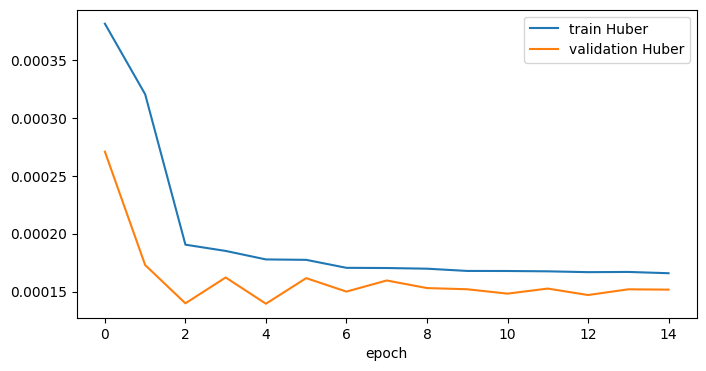

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train Huber')
plt.plot(val_losses, label='validation Huber')
plt.xlabel('epoch')
plt.legend()
plt.show()

## Финальная оценка на test

До этой ячейки test не используется ни для настройки optimizer, ни для scheduler.

In [ ]:
y_test, transformer_pred = predict_loader(model, test_dataloader)
transformer_metrics = regression_metrics(y_test, transformer_pred)
pd.Series(transformer_metrics)

,0
MAE,0.028138
RMSE,0.037837
Direction accuracy,0.489362
IC,0.066057


## Простые baseline-модели

Сложная модель должна превосходить хотя бы линейный baseline. CatBoost полезен как сильный baseline для табличных признаков; каждое временное окно здесь просто разворачивается в один вектор.

In [ ]:
def flatten_samples(samples):
  X = np.stack([x['args'].reshape(-1) for x in samples])
  y = np.array([x['target'] for x in samples])
  return X, y


X_train_flat, y_train_flat = flatten_samples(train_data)
X_val_flat, y_val_flat = flatten_samples(val_data)
X_test_flat, y_test_flat = flatten_samples(test_data)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_flat, y_train_flat)
ridge_pred = ridge.predict(X_test_flat)

catboost = CatBoostRegressor(
    iterations=400,
    depth=6,
    learning_rate=0.03,
    loss_function='RMSE',
    verbose=False,
    random_seed=42
)
catboost.fit(
    X_train_flat,
    y_train_flat,
    eval_set=(X_val_flat, y_val_flat),
    early_stopping_rounds=50,
    verbose=False
)
catboost_pred = catboost.predict(X_test_flat)

comparison = pd.DataFrame({
    'Transformer': regression_metrics(y_test_flat, transformer_pred),
    'Ridge': regression_metrics(y_test_flat, ridge_pred),
    'CatBoost': regression_metrics(y_test_flat, catboost_pred)
}).T
comparison

,MAE,RMSE,Direction accuracy,IC
Transformer,0.028138,0.037837,0.489362,0.066057
Ridge,0.033110,0.044779,0.512766,0.010185
CatBoost,0.028052,0.037187,0.419149,-0.098330


## Простая проверка торгового сигнала

Для `horizon > 1` дневные targets перекрываются, поэтому для этой грубой оценки берутся неперекрывающиеся точки с шагом `horizon`. Комиссия задаётся в базисных пунктах на изменение позиции.

In [ ]:
def strategy_metrics(y_true, y_pred, horizon=5, cost_bps=0):
  y_true = np.asarray(y_true)[::horizon]
  y_pred = np.asarray(y_pred)[::horizon]

  position = np.sign(y_pred)
  turnover = np.abs(np.diff(np.r_[0, position]))
  costs = turnover * cost_bps / 10000
  strategy_ret = position * y_true - costs

  equity = np.exp(np.cumsum(strategy_ret))
  peak = np.maximum.accumulate(equity)
  drawdown = equity / peak - 1

  periods_per_year = 252 / horizon
  sharpe = np.nan
  if strategy_ret.std() > 0:
    sharpe = strategy_ret.mean() / strategy_ret.std() * np.sqrt(periods_per_year)

  return {
      'Cumulative return': equity[-1] - 1,
      'Sharpe': sharpe,
      'Max drawdown': drawdown.min()
  }


financial_comparison = pd.DataFrame({
    'Transformer': strategy_metrics(y_test_flat, transformer_pred, horizon, cost_bps=5),
    'Ridge': strategy_metrics(y_test_flat, ridge_pred, horizon, cost_bps=5),
    'CatBoost': strategy_metrics(y_test_flat, catboost_pred, horizon, cost_bps=5)
}).T
financial_comparison

,Cumulative return,Sharpe,Max drawdown
Transformer,-0.132500,-0.299704,-0.291391
Ridge,0.143133,0.282106,-0.268636
CatBoost,-0.405447,-1.109430,-0.529286


## Walk-forward проверка CatBoost

Это более честная проверка устойчивости модели во времени. На каждом fold модель обучается только на прошлом, а scaler пересчитывается только по данным, доступным к этому моменту.

In [ ]:
def make_flat_windows(data, targets, origins, window):
  X = np.stack([data[i - window + 1:i + 1].reshape(-1) for i in origins])
  y = targets[origins]
  return X, y


def walk_forward_catboost(features, targets, window, horizon, n_splits=5):
  origins = np.arange(window - 1, len(features) - horizon)
  splitter = TimeSeriesSplit(n_splits=n_splits, gap=horizon)
  rows = []

  for fold, (train_pos, val_pos) in enumerate(splitter.split(origins), 1):
    train_origins = origins[train_pos]
    val_origins = origins[val_pos]

    fold_scaler = StandardScaler()
    fold_scaler.fit(features.iloc[:train_origins[-1] + 1])
    scaled = fold_scaler.transform(features)

    X_tr, y_tr = make_flat_windows(scaled, targets, train_origins, window)
    X_va, y_va = make_flat_windows(scaled, targets, val_origins, window)

    model_cb = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.03,
        loss_function='RMSE',
        verbose=False,
        random_seed=42
    )
    model_cb.fit(X_tr, y_tr, verbose=False)
    pred = model_cb.predict(X_va)

    row = regression_metrics(y_va, pred)
    row['fold'] = fold
    rows.append(row)

  return pd.DataFrame(rows).set_index('fold')


walk_forward_results = walk_forward_catboost(
    features,
    target,
    window=window,
    horizon=horizon,
    n_splits=5
)
walk_forward_results

,MAE,RMSE,Direction accuracy,IC
fold,,,,
1,0.017181,0.022328,0.515504,-0.014799
2,0.019004,0.030941,0.596899,0.074492
3,0.028767,0.051984,0.542636,-0.131423
4,0.022333,0.030830,0.467054,0.016430
5,0.028216,0.037450,0.408915,-0.117358


In [ ]:
walk_forward_results.mean()

,0
MAE,0.023100
RMSE,0.034707
Direction accuracy,0.506202
IC,-0.034532
